In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from energyflow import EFP
from energyflow import EFPSet
import time

# define restricted set of EFPs we will use as features

In [3]:
#EFPs (features x) and thrust (labels y)

def _compute_z_theta_t(events):
    E  = events[..., 0]
    p3 = events[..., 1:4]
    z = 2.0 * E / E.sum(dim=-1, keepdim=True)
    pmag = torch.linalg.norm(p3, dim=-1)
    pdot = torch.einsum('...ia,...ja->...ij', p3, p3)
    denom = pmag.unsqueeze(-1) * pmag.unsqueeze(-2)
    cos_th = torch.where(denom > 0, pdot / denom.clamp_min(1e-30),
                         torch.zeros_like(pdot))
    N = events.shape[-2]
    eye = torch.eye(N, dtype=cos_th.dtype, device=cos_th.device).expand_as(cos_th)
    cos_th = torch.where(eye.bool(), torch.ones_like(cos_th), cos_th)
    return z, 0.5 * (1.0 - cos_th)


def compute_special_torch(events_np, dmax, device='cpu', dtype=torch.float32):
    events = torch.as_tensor(events_np, dtype=dtype, device=device)
    z, th = _compute_z_theta_t(events)
    zz = z.unsqueeze(-1) * z.unsqueeze(-2)

    # powers of theta: Ap[k] = theta^(k+2)
    Ap = [th * th]
    for _ in range(dmax - 2):
        Ap.append(Ap[-1] * th)

    # type 1: sum_ij z_i z_j theta_ij^m
    type1 = torch.stack([(zz * a).sum(dim=(-2, -1)) for a in Ap], dim=-1)

    # s_cache[k] = sum_j z_j theta_ij^(k+2)
    s_cache = [(a * z.unsqueeze(-2)).sum(dim=-1) for a in Ap]
    t2_keys = [(p, q) for p in range(2, dmax + 1)
                      for q in range(p, dmax + 1) if p + q <= dmax]
    type2 = torch.stack([(z * s_cache[p - 2] * s_cache[q - 2]).sum(dim=-1)
                         for p, q in t2_keys], dim=-1)

    # type 3 triangle: for each (s, t) precompute M = A^s @ (diag(z) A^t)
    A = [th]
    for _ in range(dmax - 1):
        A.append(A[-1] * th)
    t3_keys = [(r, s, t) for r in range(1, dmax + 1)
                         for s in range(r, dmax + 1)
                         for t in range(s, dmax + 1) if r + s + t <= dmax]
    M_cache, t3_cols = {}, []
    for r, s, t in t3_keys:
        if (s, t) not in M_cache:
            M_cache[(s, t)] = A[s - 1] @ (z.unsqueeze(-1) * A[t - 1])
        t3_cols.append((zz * A[r - 1] * M_cache[(s, t)]).sum(dim=(-2, -1)))
    type3 = torch.stack(t3_cols, dim=-1)
    return torch.cat([type1, type2, type3], dim=-1)

## Custom ridge learning-curve function (ridge parameter is called alpha, conventions for scaling with respect to dataset size are from Cengiz's paper https://arxiv.org/abs/2405.00592)

In [4]:
def ridge_learning_curve(X, y, train_sizes, *, n_test=20000, alpha=1e-4,
                         n_repeats=200, scale=True, seed_base=0, verbose=True):
    """Test-MSE learning curve for ridge regression, paper convention.

    Matches Eq. (145) of arXiv:2405.00592v3. The empirical risk is

        L(w) = (1/n) ||X w - y||^2 + alpha ||w||^2,

    stationarity of which gives

        beta = (X^T X + n*alpha I)^{-1} X^T y       (no intercept).

    Predictions are ``pred = X_test @ beta``. When ``alpha == 0`` the function
    falls back to ``np.linalg.lstsq``: ordinary LS for n > p, minimum-norm
    interpolation for n < p.

    The last ``n_test`` rows of (X, y) are held out as the test set; for each
    ``n`` in ``train_sizes``, ``n_repeats`` subsamples of size n are drawn
    without replacement from the rest and fit independently.

    ``scale=True`` standardizes features by the *pool* (mean, std) AND
    subtracts the *pool* mean of y from both pool and test labels. The
    y-centering is the symmetric partner of the X-centering: without it
    ``pred = X_test @ beta`` is forced to have zero mean while y_test is
    not, so MSE would asymptote to ``y_pool.mean()**2`` regardless of alpha
    or n. The std of y is *not* rescaled.

    Parameters
    ----------
    X : array-like, shape (N, p)        features (numpy or torch)
    y : array-like, shape (N,)          labels (numpy or torch)
    train_sizes : sequence of int       training sizes to sweep
    n_test : int                        held-out test rows (taken from the end)
    alpha : float >= 0                  ridge strength (per-sample-loss convention)
    n_repeats : int                     random subsamples per training size
    scale : bool                        standardize X and center y by pool stats
    seed_base : int                     subsample s uses RNG seed seed_base + s
    verbose : bool                      print per-size progress

    Returns
    -------
    sizes : (K,) int ndarray
    mean_mse : (K,) float ndarray
    std_mse  : (K,) float ndarray
    """
    def _to_np(a):
        return a.detach().cpu().numpy() if hasattr(a, "detach") else np.asarray(a)
    X_np = _to_np(X).astype(np.float64, copy=False)
    y_np = _to_np(y).astype(np.float64, copy=False)
    if X_np.ndim != 2 or y_np.ndim != 1 or X_np.shape[0] != y_np.shape[0]:
        raise ValueError(f"X must be (N,p), y must be (N,); got {X_np.shape}, {y_np.shape}")
    if alpha < 0:
        raise ValueError(f"alpha must be >= 0 (got {alpha})")
    N = X_np.shape[0]
    if n_test >= N:
        raise ValueError(f"n_test ({n_test}) >= N ({N})")

    X_pool, y_pool = X_np[:-n_test], y_np[:-n_test]
    X_test, y_test = X_np[-n_test:], y_np[-n_test:]

    if scale:
        mu = X_pool.mean(axis=0)
        sd = X_pool.std(axis=0)
        sd[sd == 0] = 1.0
        X_pool = (X_pool - mu) / sd
        X_test = (X_test - mu) / sd
        # Symmetric partner of X-centering: centering X by the pool mean
        # forces predictions to have zero mean, so y must lose its pool mean
        # too or MSE floors at y_pool.mean()**2.
        y_mu = y_pool.mean()
        y_pool = y_pool - y_mu
        y_test = y_test - y_mu

    p = X_pool.shape[1]
    pool_size = X_pool.shape[0]
    diag_idx = np.arange(p)
    sizes = np.asarray(list(train_sizes), dtype=np.int64)
    mean_mse = np.empty(len(sizes))
    std_mse  = np.empty(len(sizes))

    if verbose:
        mode = "ridgeless (lstsq, min-norm)" if alpha == 0 else f"ridge alpha={alpha:g}"
        print(f"mode: {mode}")
        print(f"{'n':>8}{'mean MSE':>15}{'std MSE':>15}{'time (s)':>12}")

    for k, n in enumerate(sizes):
        if n > pool_size:
            raise ValueError(f"train size {n} > pool size {pool_size}")
        t0 = time.perf_counter()
        losses = np.empty(n_repeats)
        for s in range(n_repeats):
            rng = np.random.default_rng(int(seed_base) + s)
            idx = rng.choice(pool_size, size=n, replace=False)
            X_sub = X_pool[idx]
            y_sub = y_pool[idx]
            if alpha > 0:
                # Paper convention: (X^T X + n*alpha I) beta = X^T y
                G = X_sub.T @ X_sub
                G[diag_idx, diag_idx] += alpha * n
                b = X_sub.T @ y_sub
                beta = np.linalg.solve(G, b)
            else:
                # Ridgeless: SVD pseudoinverse; ordinary LS for n > p,
                # minimum-norm interpolator for n < p.
                beta, *_ = np.linalg.lstsq(X_sub, y_sub, rcond=None)
            pred = X_test @ beta
            losses[s] = np.mean((pred - y_test) ** 2)
        mean_mse[k] = losses.mean()
        std_mse[k]  = losses.std()
        dt = time.perf_counter() - t0
        if verbose:
            print(f"{n:>8d}{mean_mse[k]:>15.6e}{std_mse[k]:>15.6e}{dt:>12.2f}")

    return sizes, mean_mse, std_mse

@torch.no_grad()
def ridge_learning_curve_torch(X, y, train_sizes, *, n_test=5000, alpha=1e-12,
                                 n_repeats=200, scale=True, seed_base=0,
                                 device="mps", dtype=torch.float32, verbose=True):
    X = torch.as_tensor(X, dtype=dtype, device=device)            # no-op if already on GPU
    y = torch.as_tensor(y, dtype=dtype, device=device).reshape(-1)
    Xp, yp, Xt, yt = X[:-n_test], y[:-n_test], X[-n_test:], y[-n_test:]
    if scale:
      mu, sd = Xp.mean(0), Xp.std(0); sd = torch.where(sd == 0, torch.ones_like(sd), sd)
      Xp, Xt = (Xp - mu) / sd, (Xt - mu) / sd
      ymu = yp.mean(); yp, yt = yp - ymu, yt - ymu
    pool, p = Xp.shape
    eye = torch.eye(p, device=device, dtype=dtype)
    sizes = list(train_sizes); means, stds = [], []
    for n in sizes:
      t0 = time.perf_counter(); losses = torch.empty(n_repeats, device=device, dtype=dtype)
      for s in range(n_repeats):
          g = torch.Generator(device=device).manual_seed(seed_base + s)
          idx = torch.randint(pool, (n,), generator=g, device=device)   # n << pool
          Xs, ys = Xp[idx], yp[idx]
          beta = torch.linalg.solve(Xs.T @ Xs + (alpha * n) * eye, Xs.T @ ys)
          losses[s] = ((Xt @ beta - yt) ** 2).mean()
      means.append(losses.mean().item()); stds.append(losses.std().item())
      if verbose: print(f"{n:>8d}{means[-1]:>15.6e}{stds[-1]:>15.6e}{time.perf_counter()-t0:>12.2f}")
    return np.asarray(sizes), np.asarray(means), np.asarray(stds)

# import training data: $H \to gg$ vs. $\gamma \to q \bar{q}$ at 700 GeV, segmented by number of branchings 

Below, $N$ refers to total number of final-state particles (so $k$ branchings means $N = k+2$ particles).

In [22]:
Ns = [3,4,10,15,20]

events={}
labels={}
EFPs={}

for N in Ns:
    qq = torch.tensor(np.load(f'pythia_ecm_700/splittings_{N-2}.npy'))
    gg = torch.tensor(np.load(f'pythia_gluon_700/splittings_{N-2}.npy'))
    nevq = qq.shape[0]
    nevg = qq.shape[0]
    events[f'N{N}'] = np.concatenate((qq,gg))
    labels[f'N{N}']= np.ones(nevq+nevg) #gluons have label 1
    labels[f'N{N}'][:nevq] = np.zeros(nevq) #quarks have label 0
    #shuffle events
    idx = np.random.permutation(nevq+nevg)
    events[f'N{N}'] = events[f'N{N}'][idx]
    labels[f'N{N}'] = labels[f'N{N}'][idx]
    
    #compute EFPs up to max degree d = 20
    EFPs['d20',f'N{N}']= compute_special_torch(events[f'N{N}'],20,device='mps').cpu().numpy()

In [23]:
for N in Ns:
    print(labels[f'N{N}'].shape)

(199998,)
(199996,)
(197238,)
(179852,)
(143124,)


# compute ridge regression with fixed ridge parameter

In [54]:
train_sizes_t = np.logspace(np.log10(3.),np.log10(120000.),20).astype('int')
mean_mse={}
std_mse={}

alphaval = 1e-12

for N in Ns:
        
    _, mean_mse['d20',f'N{N}'], std_mse['d20',f'N{N}'] = ridge_learning_curve(
    EFPs['d20',f'N{N}'], labels[f'N{N}'],
    train_sizes=train_sizes_t,
    n_test=10000,
    alpha=alphaval,
    n_repeats=200,
    scale=True
    )

mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
       3   4.558636e+01   4.293181e+02        0.31
       5   4.324609e+02   3.429946e+03        0.41
       9   5.515245e+05   7.596910e+06        0.40
      15   3.040484e+05   1.865746e+06        0.56
      27   9.982054e+03   4.657874e+04        0.51
      48   1.085222e+02   8.769840e+02        0.46
      85   7.830493e-01   6.757419e-01        0.38
     148   3.553973e-01   1.536259e-01        0.55
     259   2.721931e-01   5.529339e-02        0.52
     453   2.355969e-01   1.530551e-02        0.75
     792   2.243168e-01   4.238451e-03        0.68
    1385   2.194563e-01   1.727502e-03        0.86
    2419   2.171785e-01   1.013574e-03        1.44
    4225   2.158139e-01   5.495343e-04        1.59
    7380   2.151163e-01   3.416921e-04        2.61
   12892   2.147317e-01   2.186231e-04        4.62
   22518   2.145268e-01   1.455073e-04        7.07
   39332   2.144000e-01   1.007083e-04       13.46
   6870

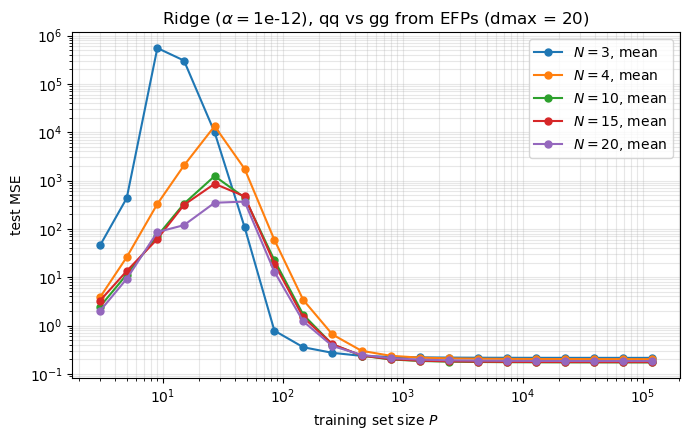

In [55]:
plt.figure(figsize=(7, 4.5))

plt.plot(train_sizes_t, mean_mse['d20','N3'],'o-',markersize=5,
             label=r'$N = 3$, mean')
plt.plot(train_sizes_t, mean_mse['d20','N4'],'o-',markersize=5,
             label=r'$N = 4$, mean')
plt.plot(train_sizes_t, mean_mse['d20','N10'],'o-',markersize=5,
             label=r'$N = 10$, mean')
plt.plot(train_sizes_t, mean_mse['d20','N15'],'o-',markersize=5,
             label=r'$N = 15$, mean')
plt.plot(train_sizes_t, mean_mse['d20','N20'],'o-',markersize=5,
             label=r'$N = 20$, mean')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('training set size $P$')
plt.ylabel('test MSE')
plt.title(rf'Ridge ($\alpha=${alphaval:g}), qq vs gg from EFPs (dmax = 20)')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# approach to loss floor for varying number of splittings

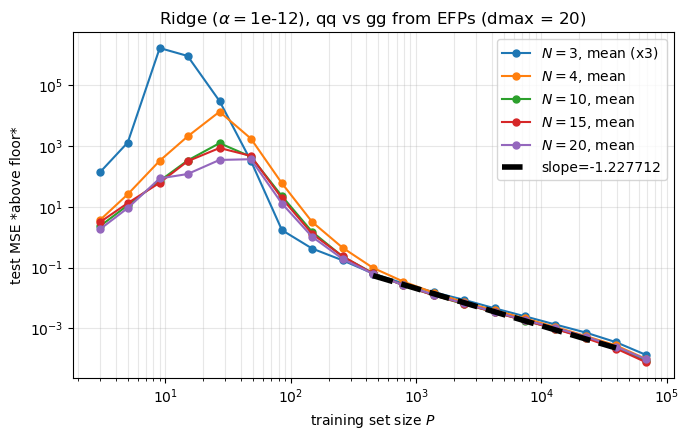

In [56]:
plt.figure(figsize=(7, 4.5))

#rescale N = 3 by hand
plt.plot(train_sizes_t[:-1], 3*(mean_mse['d20','N3'][:-1]-mean_mse['d20','N3'][-1]),'o-',markersize=5,
              label=r'$N = 3$, mean (x3)')
plt.plot(train_sizes_t[:-1], mean_mse['d20','N4'][:-1]-mean_mse['d20','N4'][-1],'o-',markersize=5,
             label=r'$N = 4$, mean')
plt.plot(train_sizes_t[:-1], mean_mse['d20','N10'][:-1]-mean_mse['d20','N10'][-1],'o-',markersize=5,
             label=r'$N = 10$, mean')
plt.plot(train_sizes_t[:-1], (mean_mse['d20','N15'][:-1]-mean_mse['d20','N15'][-1]),'o-',markersize=5,
             label=r'$N = 15$, mean')
plt.plot(train_sizes_t[:-1], (mean_mse['d20','N20'][:-1]-mean_mse['d20','N20'][-1]),'o-',markersize=5,
             label=r'$N = 20$, mean')

slope, log_c = np.polyfit(np.log(train_sizes_t[-11:-2]), np.log(mean_mse['d20','N15'][-11:-2]-mean_mse['d20','N15'][-1]), 1)
plt.plot(train_sizes_t[-11:-2],np.exp(log_c)*(train_sizes_t[-11:-2])**(slope),lw=4,linestyle='--',color='k',label=f'slope={slope:3f}')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('training set size $P$')
plt.ylabel('test MSE *above floor*')
plt.title(rf'Ridge ($\alpha=${alphaval:g}), qq vs gg from EFPs (dmax = 20)')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# look at the floor as a function of different numbers of splittings

In [43]:
floors={}
for N in range(3,20,2):
    qq = torch.tensor(np.load(f'pythia_ecm_700/splittings_{N-2}.npy'))
    gg = torch.tensor(np.load(f'pythia_gluon_700/splittings_{N-2}.npy'))
    nevq = qq.shape[0]
    nevg = qq.shape[0]
    ev = np.concatenate((qq,gg))
    Y= np.ones(nevq+nevg) #gluons have label 1
    Y[:nevq] = np.zeros(nevq) #quarks have label 0
    #shuffle events
    idx = np.random.permutation(nevq+nevg)
    ev = ev[idx]
    Y = Y[idx]
    
    #compute EFPs up to max degree d = 20
    X = compute_special_torch(ev,20,device='mps').cpu().numpy()

    _, floors['d20',f'N{N}'], _ = ridge_learning_curve(
    X, Y,
    train_sizes=[100000],
    n_test=10000,
    alpha=1e-12,
    n_repeats=200,
    scale=True
    )

mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   2.167875e-01   6.502000e-05       27.72
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.919138e-01   6.613155e-05       28.35
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.792637e-01   6.370481e-05       27.03
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.777762e-01   6.342370e-05       27.70
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.729396e-01   7.612037e-05       33.40
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.715809e-01   7.322995e-05       30.49
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.723567e-01   7.209179e-05       31.19
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.756134e-01   7.135391e-05     

In [45]:
floors['d20','N5'][0]

0.19191377623103142

Text(0.5, 1.0, 'Loss floor for qq vs gg classification from EFPs (dmax = 20)')

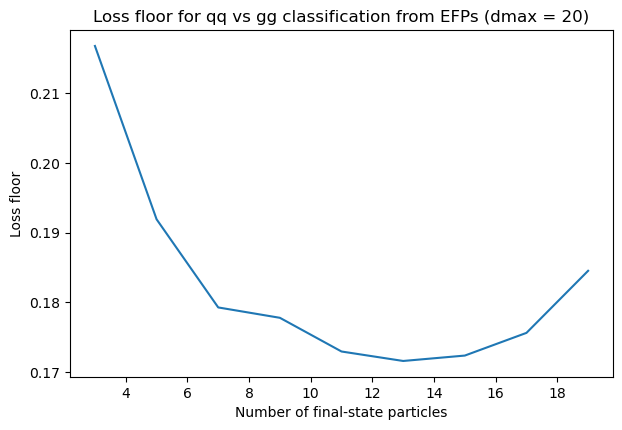

In [49]:
plt.figure(figsize=(7, 4.5))
plt.plot([N for N in range(3,20,2)],[floors['d20',f'N{N}'][0] for N in range(3,20,2)])
plt.xlabel('Number of final-state particles')
plt.ylabel('Loss floor')
plt.title('Loss floor for qq vs gg classification from EFPs (dmax = 20)')

# now try the usual set of EFPs organized by degree

In [50]:
efpsetd6 = EFPSet(('d<=', 6), measure='eeefm', beta=2,coords='epxpypz')

for N in range(3,20,2):
    qq = np.load(f'pythia_ecm_700/splittings_{N-2}.npy')
    gg = np.load(f'pythia_gluon_700/splittings_{N-2}.npy')
    nevq = qq.shape[0]
    nevg = qq.shape[0]
    ev = np.concatenate((qq,gg))
    Y= np.ones(nevq+nevg) #gluons have label 1
    Y[:nevq] = np.zeros(nevq) #quarks have label 0
    #shuffle events
    idx = np.random.permutation(nevq+nevg)
    ev = ev[idx]
    Y = Y[idx]
    
    X = efpsetd6.batch_compute(ev)

    _, floors['d6standard',f'N{N}'], _ = ridge_learning_curve(
    X, Y,
    train_sizes=[100000],
    n_test=10000,
    alpha=1e-12,
    n_repeats=200,
    scale=True
    )

mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.955327e-01   4.613302e-05       24.74
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.909797e-01   5.621349e-05       25.27
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.834860e-01   5.099643e-05       32.56
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.764432e-01   4.721730e-05       25.71
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.774122e-01   4.661399e-05       24.54
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.744575e-01   4.495310e-05       24.95
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.763069e-01   5.495759e-05       23.29
mode: ridge alpha=1e-12
       n       mean MSE        std MSE    time (s)
  100000   1.852495e-01   4.284515e-05     

Text(0.5, 1.0, 'Loss floor for qq vs gg classification from EFP package (dmax = 6)')

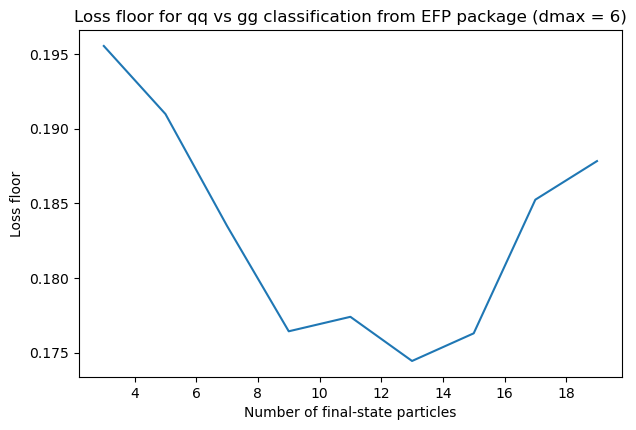

In [53]:
plt.figure(figsize=(7, 4.5))
plt.plot([N for N in range(3,20,2)],[floors['d6standard',f'N{N}'][0] for N in range(3,20,2)])
plt.xlabel('Number of final-state particles')
plt.ylabel('Loss floor')
plt.title('Loss floor for qq vs gg classification from EFP package (dmax = 6)')